In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os, numpy as np, tensorflow as tf, random
if not os.path.exists('/content/drive'):
    from google.colab import drive
    drive.mount('/content/drive')
os.makedirs('/content/drive/MyDrive/CIFAR_Assignment', exist_ok=True)
SEED=42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)
from tensorflow.keras.datasets import cifar10
(xtr,ytr),(xte,yte)=cifar10.load_data()
X=np.concatenate([xtr,xte],axis=0).astype('float32')/255.0
y=np.concatenate([ytr,yte],axis=0)
idx=np.random.RandomState(SEED).permutation(len(X))
split=int(0.8*len(X))
X_train,X_test=X[idx[:split]],X[idx[split:]]
y_train,y_test=y[idx[:split]],y[idx[split:]]
np.save('/content/drive/MyDrive/CIFAR_Assignment/X_train.npy',X_train)
np.save('/content/drive/MyDrive/CIFAR_Assignment/X_test.npy',X_test)
np.save('/content/drive/MyDrive/CIFAR_Assignment/y_train.npy',y_train)
np.save('/content/drive/MyDrive/CIFAR_Assignment/y_test.npy',y_test)
print('tf',tf.__version__,'gpu',tf.config.list_physical_devices('GPU'))
print('X_train',X_train.shape,'X_test',X_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
tf 2.19.0 gpu []
X_train (48000, 32, 32, 3) X_test (12000, 32, 32, 3)


In [ ]:
import os, json, numpy as np, tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Input
from tensorflow.keras.callbacks import ModelCheckpoint, CSVLogger, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input

base_dir='/content/drive/MyDrive/CIFAR_Assignment'
X_train=np.load(base_dir+'/X_train.npy')
X_test=np.load(base_dir+'/X_test.npy')
y_train=np.load(base_dir+'/y_train.npy').ravel()
y_test=np.load(base_dir+'/y_test.npy').ravel()

val_size=int(0.1*len(X_train))
X_tr, X_val = X_train[:-val_size], X_train[-val_size:]
y_tr, y_val = y_train[:-val_size], y_train[-val_size:]

AUTOTUNE=tf.data.AUTOTUNE
IMAGE_SIZE=64
BATCH_SIZE=128
EPOCHS=4

def make_ds(X,y,shuffle=False):
    ds=tf.data.Dataset.from_tensor_slices((X,y))
    ds=ds.map(lambda a,b:(tf.image.resize(a,[IMAGE_SIZE,IMAGE_SIZE]), tf.one_hot(b,10)), num_parallel_calls=AUTOTUNE)
    ds=ds.map(lambda a,b:(preprocess_input(a*255.0), b), num_parallel_calls=AUTOTUNE)
    if shuffle: ds=ds.shuffle(4096,seed=42)
    ds=ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds=make_ds(X_tr,y_tr,shuffle=True)
val_ds=make_ds(X_val,y_val,shuffle=False)
test_ds=make_ds(X_test,y_test,shuffle=False)

inp=Input(shape=(IMAGE_SIZE,IMAGE_SIZE,3))
base=VGG16(include_top=False, weights='imagenet', input_tensor=inp)
base.trainable=False
x=GlobalAveragePooling2D()(base.output)
x=Dense(128,activation='relu')(x)
x=Dropout(0.3)(x)
out=Dense(10,activation='softmax')(x)
model=Model(inputs=base.input,outputs=out)

model.compile(optimizer=tf.keras.optimizers.Adam(1e-4), loss='categorical_crossentropy', metrics=['accuracy'])

os.makedirs(base_dir+'/checkpoints',exist_ok=True)
ckpt=ModelCheckpoint(base_dir+'/checkpoints/vgg16_cpu_best.h5',monitor='val_accuracy',save_best_only=True,mode='max')
csv=CSVLogger(base_dir+'/vgg16_cpu_history.csv',append=False)
es=EarlyStopping(monitor='val_loss',patience=3,restore_best_weights=True)
rlr=ReduceLROnPlateau(monitor='val_loss',factor=0.5,patience=2)
callbacks=[ckpt,csv,es,rlr]

print(model.summary())
history=model.fit(train_ds,epochs=EPOCHS,validation_data=val_ds,callbacks=callbacks,verbose=1)

with open(base_dir+'/vgg16_cpu_history.json','w') as f: json.dump(history.history,f)
res=model.evaluate(test_ds,verbose=1)
print('test_loss',res[0],'test_acc',res[1])
print('saved:', base_dir+'/checkpoints/vgg16_cpu_best.h5', base_dir+'/vgg16_cpu_history.csv', base_dir+'/vgg16_cpu_history.json')


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 64, 64, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 8, 8, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,781,642 (56.39 MB)

 Trainable params: 66,954 (261.54 KB)

...

None
Epoch 1/4
338/338 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.2288 - loss: 8.0271

338/338 ━━━━━━━━━━━━━━━━━━━━ 2464s 7s/step - accuracy: 0.2291 - loss: 8.0196 - val_accuracy: 0.5169 - val_loss: 2.0539 - learning_rate: 1.0000e-04
Epoch 2/4
338/338 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.4672 - loss: 2.5289

338/338 ━━━━━━━━━━━━━━━━━━━━ 2451s 7s/step - accuracy: 0.4672 - loss: 2.5282 - val_accuracy: 0.5821 - val_loss: 1.4633 - learning_rate: 1.0000e-04
Epoch 3/4
338/338 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.5183 - loss: 1.7616

338/338 ━━━━━━━━━━━━━━━━━━━━ 2441s 7s/step - accuracy: 0.5184 - loss: 1.7614 - val_accuracy: 0.6115 - val_loss: 1.2555 - learning_rate: 1.0000e-04
Epoch 4/4
338/338 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.5618 - loss: 1.4637

338/338 ━━━━━━━━━━━━━━━━━━━━ 2499s 7s/step - accuracy: 0.5618 - loss: 1.4636 - val_accuracy: 0.6367 - val_loss: 1.1378 - learning_rate: 1.0000e-04
94/94 ━━━━━━━━━━━━━━━━━━━━ 604s 6s/step - accuracy: 0.6354 - loss: 1.1295
test_loss 1.1300128698349 test_acc 0.6344166398048401
saved: /content/drive/MyDrive/CIFAR_Assignment/checkpoints/vgg16_cpu_best.h5 /content/drive/MyDrive/CIFAR_Assignment/vgg16_cpu_history.csv /content/drive/MyDrive/CIFAR_Assignment/vgg16_cpu_history.json


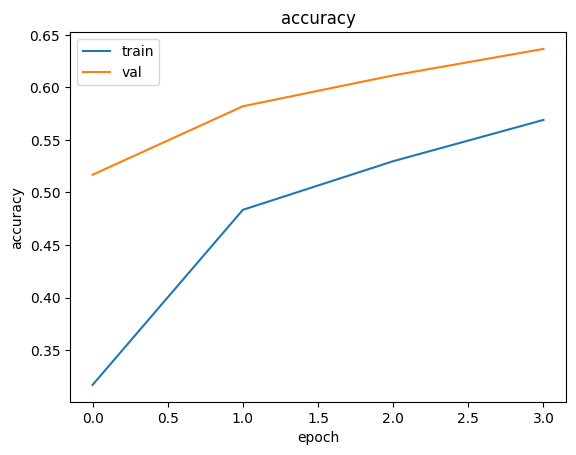

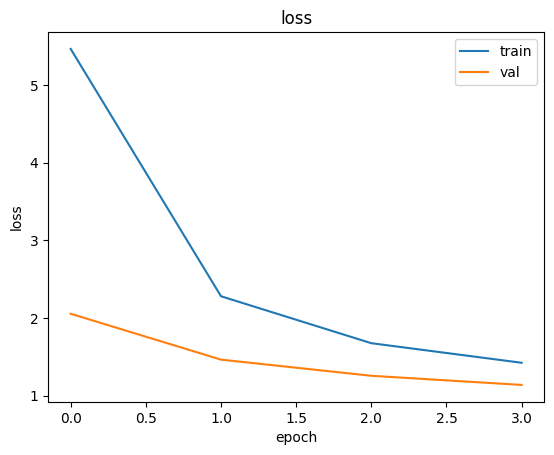

test_loss 1.1300123929977417 test_acc 0.6344166398048401


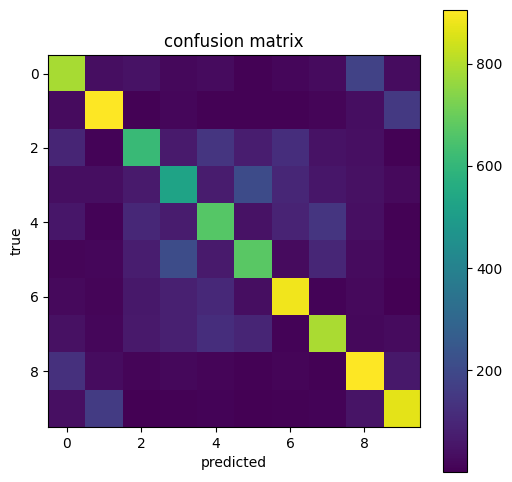

              precision    recall  f1-score   support

    airplane     0.6346    0.6669    0.6504      1177
  automobile     0.7375    0.7729    0.7548      1167
        bird     0.5872    0.5054    0.5432      1213
         cat     0.4781    0.4525    0.4650      1158
        deer     0.5444    0.5480    0.5462      1219
         dog     0.5825    0.5543    0.5681      1216
        frog     0.6911    0.7111    0.7009      1246
       horse     0.6614    0.6267    0.6436      1259
        ship     0.6669    0.7561    0.7087      1197
       truck     0.7323    0.7552    0.7436      1148

    accuracy                         0.6344     12000
   macro avg     0.6316    0.6349    0.6324     12000
weighted avg     0.6315    0.6344    0.6321     12000



Saved: /content/drive/MyDrive/CIFAR_Assignment/figures/vgg16_accuracy.png /content/drive/MyDrive/CIFAR_Assignment/figures/vgg16_loss.png /content/drive/MyDrive/CIFAR_Assignment/figures/vgg16_confusion_matrix.png /content/drive/MyDrive/CIFAR_Assignment/figures/vgg16_classification_report.txt /content/drive/MyDrive/CIFAR_Assignment/vgg16_cpu_summary.txt


In [ ]:
import os, json, numpy as np, tensorflow as tf
from matplotlib import pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.applications.vgg16 import preprocess_input
base_dir='/content/drive/MyDrive/CIFAR_Assignment'
with open(base_dir+'/vgg16_cpu_history.json','r') as f: h=json.load(f)
acc=h.get('accuracy',[])
val_acc=h.get('val_accuracy',[])
loss=h.get('loss',[])
val_loss=h.get('val_loss',[])
os.makedirs(base_dir+'/figures',exist_ok=True)
plt.figure(); plt.plot(acc); plt.plot(val_acc); plt.title('accuracy'); plt.xlabel('epoch'); plt.ylabel('accuracy'); plt.legend(['train','val']); plt.savefig(base_dir+'/figures/vgg16_accuracy.png',bbox_inches='tight'); plt.show()
plt.figure(); plt.plot(loss); plt.plot(val_loss); plt.title('loss'); plt.xlabel('epoch'); plt.ylabel('loss'); plt.legend(['train','val']); plt.savefig(base_dir+'/figures/vgg16_loss.png',bbox_inches='tight'); plt.show()
X_test=np.load(base_dir+'/X_test.npy')
y_test=np.load(base_dir+'/y_test.npy').ravel()
Xr=tf.image.resize(X_test,[64,64])
Xp=preprocess_input(Xr*255.0)
model=tf.keras.models.load_model(base_dir+'/checkpoints/vgg16_cpu_best.h5')
res=model.evaluate(Xp,tf.keras.utils.to_categorical(y_test,10),verbose=0)
print('test_loss',res[0],'test_acc',res[1])
pred=model.predict(Xp,verbose=0)
y_pred=pred.argmax(axis=1)
cm=confusion_matrix(y_test,y_pred)
plt.figure(figsize=(6,6)); plt.imshow(cm,interpolation='nearest'); plt.title('confusion matrix'); plt.colorbar(); plt.xlabel('predicted'); plt.ylabel('true'); plt.savefig(base_dir+'/figures/vgg16_confusion_matrix.png',bbox_inches='tight'); plt.show()
labels=['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']
cr=classification_report(y_test,y_pred,target_names=labels,digits=4)
print(cr)
with open(base_dir+'/figures/vgg16_classification_report.txt','w') as f: f.write(cr)
with open(base_dir+'/vgg16_cpu_summary.txt','w') as f: model.summary(print_fn=lambda x: f.write(x+'\n'))
print('Saved:', base_dir+'/figures/vgg16_accuracy.png', base_dir+'/figures/vgg16_loss.png', base_dir+'/figures/vgg16_confusion_matrix.png', base_dir+'/figures/vgg16_classification_report.txt', base_dir+'/vgg16_cpu_summary.txt')
